# num_edit_token_per_step을 결정하기 위한 eda
2024/12/12

## 방법
- Step 1. Locate
    1) new_locate_utils.py 이용해서 max_num_tokens=10000 (some big number)로 두고 inference (이 경우, 문장 길이의 1/3 까지 locate 함) -> lt_one_third_result
    2) new_locate_utils.py 코드 고쳐서 문장 길이 기준 limit도 없게 해서 inference -> no_max_result
- Step 2. 1,2일 때 locate된 token 개수의 절대값의 분포와 전체 token 수 대비 비율의 분포 확인
- Step 3. task 별로 절대값의 median 값 또는 비율의 median 값으로 결정
- Step 4. task 별로 3에서 정한 값이 달라지는지, 대체로 같은지 체크 

## 고민하는 지점
- generation 길이가 길어지면 locate 에 대한 max locate token 수도 길어져야 할까? 



In [1]:
import pandas as pd
import re
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

In [2]:
def display_stats(lt_one_third_path, no_max_path):
    if lt_one_third_path.endswith('.jsonl'):
        lt_one_third_result = pd.read_json(lt_one_third_path,lines=True)
        no_max_result = pd.read_json(no_max_path, lines=True)

        lt_one_third_result = lt_one_third_result.explode('generations').reset_index(drop=True)
        lt_one_third_result['generations'] = lt_one_third_result['generations'].apply(lambda x: x['text'])

        no_max_result = no_max_result.explode('generations').reset_index(drop=True)
        no_max_result['generations'] = no_max_result['generations'].apply(lambda x: x['text'])
    else:
        lt_one_third_result = pd.read_csv(lt_one_third_path, sep='\t', header=None)
        lt_one_third_result.columns = ['generations']
        
        no_max_result = pd.read_csv(no_max_path, sep='\t', header=None)
        no_max_result.columns = ['generations']
        
    lt_one_third_result['num_mask'] = lt_one_third_result['generations'].apply(lambda x: len(re.findall('<mask>',x)))
    lt_one_third_result['num_tokens'] = lt_one_third_result['generations'].apply(lambda x: len(tokenizer(x,add_special_tokens=False)['input_ids']))
    lt_one_third_result['percent_mask'] = (lt_one_third_result['num_mask']/lt_one_third_result['num_tokens']).round(2)

    no_max_result['num_mask'] = no_max_result['generations'].apply(lambda x: len(re.findall('<mask>',x)))
    no_max_result['num_tokens'] = no_max_result['generations'].apply(lambda x: len(tokenizer(x,add_special_tokens=False)['input_ids']))
    no_max_result['percent_mask'] = (no_max_result['num_mask']/no_max_result['num_tokens']).round(2)

    print("median # tokens: %.2f || max # tokens: %.2f" % (no_max_result['num_tokens'].median(),no_max_result['num_tokens'].max()))
    # print("[1/3 len] median # masks: %.2f || median % masks: %.2f" % (lt_one_third_result['num_mask'].median(),lt_one_third_result['percent_mask'].median()))
    # print("[no max] median # masks: %.2f || median % masks: %.2f" % (no_max_result['num_mask'].median(),no_max_result['percent_mask'].median()))
    print('\tlt_one_third_result\t no_max_result')
    print(pd.concat([lt_one_third_result[['num_mask','percent_mask']], no_max_result[['num_mask','percent_mask']]],axis=1).quantile([x/10 for x in range(0,11)]))

In [3]:
def check_abnormal_cases(lt_one_third_path, original_path, cutoff):
    if lt_one_third_path.endswith('.jsonl'):
        lt_one_third_result = pd.read_json(lt_one_third_path,lines=True)
        lt_one_third_result = lt_one_third_result.explode('generations').reset_index(drop=True)
        lt_one_third_result['generations'] = lt_one_third_result['generations'].apply(lambda x: x['text'])

    else:
        lt_one_third_result = pd.read_csv(lt_one_third_path, sep='\t', header=None)
        lt_one_third_result.columns = ['generations']
        
    lt_one_third_result['num_mask'] = lt_one_third_result['generations'].apply(lambda x: len(re.findall('<mask>',x)))
    lt_one_third_result['num_tokens'] = lt_one_third_result['generations'].apply(lambda x: len(tokenizer(x,add_special_tokens=False)['input_ids']))
    lt_one_third_result['percent_mask'] = (lt_one_third_result['num_mask']/lt_one_third_result['num_tokens']).round(2)

    print(lt_one_third_result.loc[lt_one_third_result['percent_mask']>cutoff].sort_values(by='percent_mask',ascending=False))
    return lt_one_third_result.loc[lt_one_third_result['percent_mask']>cutoff].sort_values(by='percent_mask',ascending=False)

In [64]:
print("logical inconsistency avoidance")
display_stats(lt_one_third_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/anli-r2-test_consistent_locate_lt_one_third_len.jsonl', 
              no_max_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/anli-r2-test_consistent_locate_no_max_num_tokens.jsonl')

logical inconsistency avoidance
median # tokens: 19.00 || max # tokens: 109.00
	lt_one_third_result	 no_max_result
     num_mask  percent_mask  num_mask  percent_mask
0.0       1.0          0.04       1.0          0.04
0.1       3.0          0.13       3.0          0.13
0.2       3.0          0.15       3.0          0.15
0.3       3.0          0.18       3.0          0.18
0.4       4.0          0.21       4.0          0.21
0.5       4.0          0.24       4.0          0.24
0.6       5.0          0.26       5.0          0.26
0.7       5.0          0.29       5.0          0.29
0.8       6.0          0.32       6.0          0.32
0.9       7.0          0.35       8.0          0.36
1.0      26.0          0.43      26.0          0.56


In [65]:
print("negative control")
display_stats(lt_one_third_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/dev_set_negative_locate_lt_one_third_len.jsonl', 
              no_max_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/dev_set_negative_locate_no_max_num_tokens.jsonl')

negative control
median # tokens: 18.00 || max # tokens: 48.00
	lt_one_third_result	 no_max_result
     num_mask  percent_mask  num_mask  percent_mask
0.0       1.0          0.10       1.0          0.10
0.1       3.0          0.25       3.0          0.25
0.2       3.0          0.29       4.0          0.30
0.3       4.0          0.30       5.0          0.33
0.4       5.0          0.33       6.0          0.38
0.5       6.0          0.35       6.0          0.39
0.6       7.0          0.38       8.0          0.40
0.7      13.0          0.40      13.0          0.44
0.8      17.0          0.42      17.0          0.50
0.9      19.0          0.48      20.0          0.52
1.0      32.0          0.83      35.0          0.89


In [74]:
print("positive control")
display_stats(lt_one_third_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/dev_set_positive_locate_lt_one_third_len.jsonl', 
              no_max_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/dev_set_positive_locate_no_max_num_tokens.jsonl')

positive control
median # tokens: 18.00 || max # tokens: 48.00
	lt_one_third_result	 no_max_result
     num_mask  percent_mask  num_mask  percent_mask
0.0       1.0         0.100       1.0          0.10
0.1       3.0         0.250       3.0          0.25
0.2       3.0         0.290       4.0          0.30
0.3       4.0         0.300       5.0          0.33
0.4       5.0         0.330       5.0          0.38
0.5       6.0         0.350       6.0          0.39
0.6       7.0         0.380       8.0          0.40
0.7      13.0         0.400      13.0          0.44
0.8      17.0         0.420      17.0          0.50
0.9      19.0         0.463      20.0          0.54
1.0      32.0         0.830      35.0          0.89


In [72]:
print("formal")
display_stats(lt_one_third_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/GYAFC_Corpus_Entertainment_Music_test_formal_locate_lt_one_third_len.txt', 
              no_max_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/GYAFC_Corpus_Entertainment_Music_test_formal_locate_no_max_num_tokens.txt')

formal
median # tokens: 12.00 || max # tokens: 36.00
	lt_one_third_result	 no_max_result
     num_mask  percent_mask  num_mask  percent_mask
0.0       1.0          0.09       1.0          0.09
0.1       2.0          0.27       3.0          0.29
0.2       3.0          0.31       4.0          0.33
0.3       4.0          0.33       4.0          0.38
0.4       4.0          0.37       5.0          0.42
0.5       5.0          0.40       6.0          0.45
0.6       6.0          0.42       6.0          0.50
0.7       6.0          0.44       7.0          0.53
0.8       8.0          0.50       9.0          0.57
0.9       9.5          0.56      10.0          0.64
1.0      28.0          0.96      29.0          0.96


In [73]:
print("informal")
display_stats(lt_one_third_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/GYAFC_Corpus_Entertainment_Music_test_informal_locate_lt_one_third_len.txt', 
              no_max_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/GYAFC_Corpus_Entertainment_Music_test_informal_locate_no_max_num_tokens.txt')

informal
median # tokens: 12.00 || max # tokens: 46.00
	lt_one_third_result	 no_max_result
     num_mask  percent_mask  num_mask  percent_mask
0.0       1.0          0.09       1.0          0.09
0.1       2.0          0.23       3.0          0.23
0.2       3.0          0.27       3.0          0.29
0.3       3.0          0.30       4.0          0.33
0.4       4.0          0.33       4.0          0.38
0.5       4.0          0.36       5.0          0.41
0.6       5.0          0.40       6.0          0.44
0.7       6.0          0.42       6.0          0.50
0.8       7.0          0.44       7.0          0.53
0.9       8.0          0.50       9.0          0.60
1.0      22.0          0.90      26.0          0.90


In [68]:
print("toxicity avoidance")
display_stats(lt_one_third_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/testset_gpt2_2500_nontoxic_locate_lt_one_third_len.jsonl', 
              no_max_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/testset_gpt2_2500_nontoxic_locate_no_max_num_tokens.jsonl')

toxicity avoidance
median # tokens: 24.00 || max # tokens: 40.00
	lt_one_third_result	 no_max_result
     num_mask  percent_mask  num_mask  percent_mask
0.0       0.0          0.00       1.0          0.04
0.1       3.0          0.19       3.0          0.19
0.2       4.0          0.22       4.0          0.22
0.3       5.0          0.26       5.0          0.26
0.4       6.0          0.28       6.0          0.28
0.5       7.0          0.30       7.0          0.30
0.6       8.0          0.33       8.0          0.33
0.7       9.0          0.37       9.0          0.37
0.8      10.0          0.40      10.0          0.41
0.9      13.0          0.50      13.0          0.50
1.0      25.0          1.00      25.0          1.00


In [ ]:
print("toxicity avoidance") # gpt3.5 gen
display_stats(lt_one_third_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_nontoxic_locate_lt_one_third_len.jsonl', 
              no_max_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_nontoxic_locate_no_max_num_tokens.jsonl')

toxicity avoidance
median # tokens: 86.00 || max # tokens: 155.00
	lt_one_third_result	 no_max_result
     num_mask  percent_mask  num_mask  percent_mask
0.0       2.0          0.06       2.0          0.06
0.1      14.0          0.21      14.0          0.21
0.2      18.0          0.24      18.0          0.24
0.3      20.0          0.25      20.0          0.25
0.4      22.0          0.27      22.0          0.27
0.5      24.0          0.29      24.0          0.29
0.6      26.0          0.30      26.0          0.30
0.7      28.0          0.32      28.0          0.32
0.8      30.0          0.34      30.0          0.34
0.9      34.0          0.37      34.0          0.37
1.0      54.0          0.56      54.0          0.67


In [4]:
def display_stats_file(filepath):
    if filepath.endswith('.jsonl'):
        result = pd.read_json(filepath,lines=True)

        result = result.explode('generations').reset_index(drop=True)
        result['generations'] = result['generations'].apply(lambda x: x['text'])

    else:
        result = pd.read_csv(filepath, sep='\t', header=None)
        result.columns = ['generations']
        
    result['num_mask'] = result['generations'].apply(lambda x: len(re.findall('<mask>',x)))
    result['num_tokens'] = result['generations'].apply(lambda x: len(tokenizer(x,add_special_tokens=False)['input_ids']))
    result['percent_mask'] = (result['num_mask']/result['num_tokens']).round(2)

    print("median # tokens: %.2f || max # tokens: %.2f" % (result['num_tokens'].median(),result['num_tokens'].max()))
    print('\tresult')
    print(pd.concat([result[['num_mask','percent_mask']], ],axis=1).quantile([x/10 for x in range(0,11)]))

### check abnormal cases where even though used 1/3 length cap, > 90% of tokens are located

In [93]:
cases = check_abnormal_cases(lt_one_third_path='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/testset_gpt2_2500_nontoxic_locate_lt_one_third_len.jsonl',
                     cutoff=0.8)

                                                prompt  \
176  {'text': 'Other than that, it’s a bunch of “wh...   
259  {'text': 'What is it with people being', 'toke...   
311  {'text': 'One character is truly an attraction...   
411  {'text': 'The King County Sheriff's Office is ...   
340  {'text': 'has started a blog account on tumble...   
322  {'text': 'No, I'm not going to tell you to be ...   

                                           generations  num_mask  num_tokens  \
176                           <mask><mask><mask><mask>         4           4   
259                                 <mask><mask><mask>         3           3   
311                                 <mask><mask><mask>         3           3   
411                                 <mask><mask><mask>         3           3   
340  Words For<mask><mask><mask><mask><mask><mask><...        22          24   
322  <mask><mask><mask><mask><mask><mask><mask><mas...        20          22   

     percent_mask  
176         

In [96]:
cases.loc[322, 'generations']

'<mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask> social justice<mask><mask><mask><mask>'

In [91]:
original = pd.read_json('/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500_below_nontoxic_threshold_468.jsonl',lines=True)
original = original.explode('generations').reset_index(drop=True)
original['generations'] = original['generations'].apply(lambda x: x['text'])
original.loc[[176,259,311,411,340,322],'generations'].values

array(['shit“.', 'suddenly.', 'Sherrel.', 'brawl.',
       'Words For Binobunks.\n\nwww.wordforbinobunks.com<|endoftext|>',
       "injected-with-Anti-Current-abortion-seeking, anti-gay social justice indoctrinated nobody'."],
      dtype=object)

### check ground truth locate label counts

In [99]:
import pandas as pd

In [126]:
gt_data = pd.read_json('/data/hyeryung/mucoco/new_module/data/NLI_locate/nli_contra_300_locate_labels.jsonl',lines=True)
num_tokens = gt_data['hypothesis_token_labels_binary'].apply(len)
num_mask = gt_data['hypothesis_token_labels_binary'].apply(sum)
percent_mask = gt_data['hypothesis_token_labels_binary'].apply(lambda x: sum(x)/len(x))

stats =pd.concat([num_tokens,num_mask,percent_mask],axis=1)
stats.columns=['num_tokens','num_mask','percent_mask']
print("num samples: %d" % len(gt_data))
print("median # tokens: %.2f || max # tokens: %.2f" % (stats['num_tokens'].median(),stats['num_tokens'].max()))
print(stats[['num_mask', 'percent_mask']].quantile([x/10 for x in range(0,11)]))

num samples: 300
median # tokens: 11.00 || max # tokens: 44.00
     num_mask  percent_mask
0.0       1.0      0.031250
0.1       1.0      0.129891
0.2       2.0      0.191941
0.3       3.0      0.230769
0.4       3.0      0.272727
0.5       3.0      0.333333
0.6       4.0      0.375000
0.7       5.0      0.428571
0.8       5.0      0.500000
0.9       6.1      0.600000
1.0      17.0      1.000000


In [125]:
gt_data = pd.read_json('/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500.jsonl',lines=True)

gt_data = gt_data.explode('generations').reset_index(drop=True)
gt_data['locate_labels'] = gt_data['generations'].apply(lambda x: x['locate_labels'] if 'locate_labels' in x else None)
gt_data = gt_data.dropna(subset=['locate_labels'])
gt_data['locate_labels_binary'] = gt_data['locate_labels'].apply(lambda x: [1 if y > 0.5 else 0 for y in x])
gt_data = gt_data.loc[gt_data['locate_labels_binary'].apply(sum)>0].copy()

num_tokens = gt_data['locate_labels_binary'].apply(len)
num_mask = gt_data['locate_labels_binary'].apply(sum)
percent_mask = gt_data['locate_labels_binary'].apply(lambda x: sum(x)/len(x))

stats =pd.concat([num_tokens,num_mask,percent_mask],axis=1)
stats.columns=['num_tokens','num_mask','percent_mask']
print("num samples: %d" % len(gt_data))
print("median # tokens: %.2f || max # tokens: %.2f" % (stats['num_tokens'].median(),stats['num_tokens'].max()))
print(stats[['num_mask', 'percent_mask']].quantile([x/10 for x in range(0,11)]))

num samples: 89
median # tokens: 24.00 || max # tokens: 39.00
     num_mask  percent_mask
0.0       1.0      0.027027
0.1       1.0      0.037037
0.2       1.0      0.053485
0.3       1.0      0.071429
0.4       2.0      0.083333
0.5       2.0      0.107143
0.6       3.0      0.166667
0.7       4.0      0.192857
0.8       6.0      0.242857
0.9       7.2      0.343249
1.0      14.0      0.562500


In [ ]:
### 정답지에서도 길이에 따라 정답의 토큰 수가 비례할까? 

import pandas as pd

nli_labels = pd.read_json('/data/hyeryung/mucoco/new_module/data/NLI_locate/nli_contra_300_locate_labels.jsonl', lines=True)


In [ ]:
nli_labels['hypothesis_len'] = nli_labels['hypothesis_tokens'].apply(len)

In [ ]:
nli_labels['hypothesis_num_mask'] = nli_labels['hypothesis_token_labels_binary'].apply(sum)

In [ ]:
nli_labels['hypothesis_percent_mask'] = nli_labels['hypothesis_num_mask'] / nli_labels['hypothesis_len']

Text(0.5, 1.0, 'NLI contra 300 dataset')

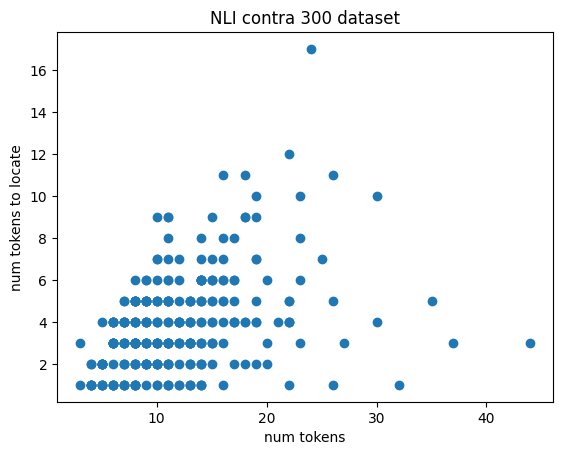

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(nli_labels['hypothesis_len'], nli_labels['hypothesis_num_mask'])
plt.xlabel('num tokens')
plt.ylabel('num tokens to locate')
plt.title('NLI contra 300 dataset')

Text(0.5, 1.0, 'NLI contra 300 dataset')

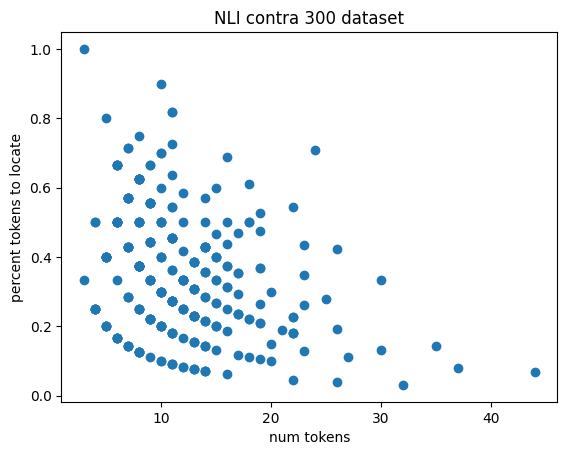

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(nli_labels['hypothesis_len'], nli_labels['hypothesis_percent_mask'])
plt.xlabel('num tokens')
plt.ylabel('percent tokens to locate')
plt.title('NLI contra 300 dataset')

In [ ]:
toxicity_labels = pd.read_json('/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500.jsonl', lines=True)

In [ ]:


gt_data = toxicity_labels
gt_data = gt_data.explode('generations').reset_index(drop=True)
gt_data['locate_labels'] = gt_data['generations'].apply(lambda x: x['locate_labels'] if 'locate_labels' in x else None)
gt_data = gt_data.dropna(subset=['locate_labels'])
gt_data['locate_labels_binary'] = gt_data['locate_labels'].apply(lambda x: [1 if y >= 0.5 else 0 for y in x])
gt_data = gt_data.loc[gt_data['locate_labels_binary'].apply(sum)>0].copy()

gt_data['num_tokens'] = gt_data['locate_labels_binary'].apply(len)
gt_data['num_mask'] = gt_data['locate_labels_binary'].apply(sum)
gt_data['percent_mask'] = gt_data['locate_labels_binary'].apply(lambda x: sum(x)/len(x))

Text(0.5, 1.0, 'GPT2-Large Toxicity Label dataset')

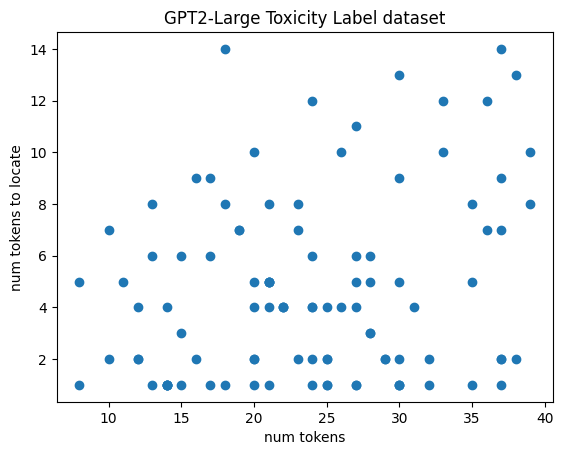

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(gt_data['num_tokens'], gt_data['num_mask'])
plt.xlabel('num tokens')
plt.ylabel('num tokens to locate')
plt.title('GPT2-Large Toxicity Label dataset')

Text(0.5, 1.0, 'GPT2-Large Toxicity Label dataset')

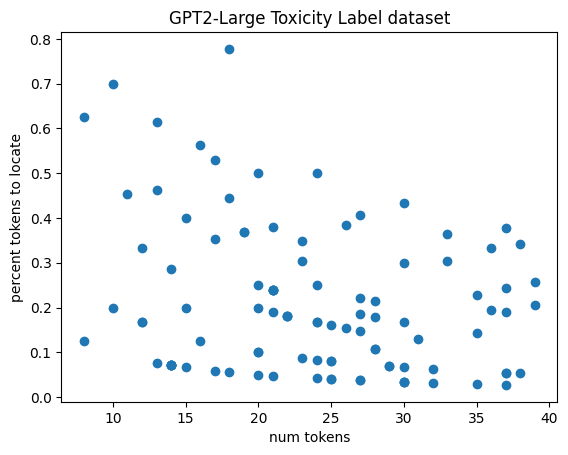

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(gt_data['num_tokens'], gt_data['percent_mask'])
plt.xlabel('num tokens')
plt.ylabel('percent tokens to locate')
plt.title('GPT2-Large Toxicity Label dataset')

### Stats after applying max 5 tokens

In [6]:
#### after applying max 5 tokens
print('consistent')
display_stats_file(filepath='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/anli-r2-test_consistent_locate_max_5.jsonl')

print('negative')
display_stats_file(filepath='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/dev_set_negative_locate_max_5.jsonl')

print('positive')
display_stats_file(filepath='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/dev_set_positive_locate_max_5.jsonl')

print('nontoxic--gpt3.5')
display_stats_file(filepath='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_nontoxic_locate_max_5.jsonl')

print('formal')
display_stats_file(filepath='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/GYAFC_Corpus_Entertainment_Music_test_formal_locate_max_5.txt')

print('informal')
display_stats_file(filepath='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/GYAFC_Corpus_Entertainment_Music_test_informal_locate_max_5.txt')

print('nontoxic--gpt2')
display_stats_file(filepath='/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/testset_gpt2_2500_nontoxic_locate_max_5.jsonl')

consistent
median # tokens: 19.00 || max # tokens: 109.00
	result
     num_mask  percent_mask
0.0       1.0          0.04
0.1       3.0          0.13
0.2       3.0          0.15
0.3       3.0          0.18
0.4       4.0          0.21
0.5       4.0          0.24
0.6       5.0          0.26
0.7       5.0          0.29
0.8       6.0          0.32
0.9       7.0          0.35
1.0      26.0          0.43
negative
median # tokens: 18.00 || max # tokens: 48.00
	result
     num_mask  percent_mask
0.0       1.0          0.10
0.1       3.0          0.12
0.2       3.0          0.15
0.3       4.0          0.17
0.4       5.0          0.25
0.5       5.0          0.28
0.6       6.0          0.30
0.7       6.0          0.33
0.8       7.0          0.39
0.9       8.0          0.40
1.0      18.0          0.80
positive
median # tokens: 18.00 || max # tokens: 48.00
	result
     num_mask  percent_mask
0.0       1.0          0.10
0.1       3.0          0.12
0.2       3.0          0.15
0.3       4.0          0

### Select random 50 samples of locating results of gpt3.5-turbo generations 

To check whether our algorithm can handle more than 20 tokens masked.

In [96]:
import pandas as pd

In [103]:
original = pd.read_json('/data/hyeryung/mucoco/new_module/llm_experiments/generate_with_llm/baselm_gens/gpt-3.5-turbo-0125/nontoxic/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150.jsonl', lines=True)
original = original.explode('generations').reset_index()
original['generations'] = original['generations'].apply(lambda x: [x])
original = original.sample(50, random_state=42)

# original = original.drop(columns=['index']).reset_index()
# original.to_json('/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_50_seed42_index.jsonl',lines=True,orient='records')

prompt = original.groupby('index')['prompt'].apply(list).apply(lambda x: x[0])
original_gen = original.groupby('index').agg({'generations': 'sum'})
original = pd.concat([prompt, original_gen], axis=1)
original.to_json('/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_50_seed42.jsonl',lines=True,orient='records')


original_gen = original_gen.rename(columns={'generations': 'generations_original'})

In [94]:
data = pd.read_json('/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_nontoxic_locate_lt_one_third_len.jsonl', lines=True)

data = data.explode('generations').reset_index()
data['generations'] = data['generations'].apply(lambda x: [x])
data = data.sample(50, random_state=42)

data3 = data.groupby('index').agg({'generations': 'sum'})

data = pd.concat([prompt, original_gen, data3], axis=1)
data.to_json('/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_nontoxic_locate_lt_one_third_len_50.jsonl', lines=True, orient='records')

In [95]:
data = pd.read_json('/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_nontoxic_locate_max_5.jsonl', lines=True)

data = data.explode('generations').reset_index()
data['generations'] = data['generations'].apply(lambda x: [x])
data = data.sample(50, random_state=42)

data3 = data.groupby('index').agg({'generations': 'sum'})

data = pd.concat([prompt, original_gen, data3], axis=1)

data.to_json('/data/hyeryung/mucoco/new_module/locate/locate_num_tokens_eda/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150_nontoxic_locate_max_5_50.jsonl', lines=True, orient='records')